# Notebook 6 — Détection d'anomalies sur les métriques — Online Boutique

## Contexte

On applique les mêmes algorithmes que le notebook 03 (Train Ticket)  
sur le deuxième système — Online Boutique.

**Objectif** : vérifier si les résultats se généralisent  
sur un système différent (Go/Python vs Java).

## Différences avec Train Ticket

| Aspect | Train Ticket | Online Boutique |
|--------|-------------|-----------------|
| Services | 41 (Java) | 12 (Go, Python, Node.js) |
| Pannes | 45 (4 types) | 56 (5 types + cpu_consumed) |
| Dates | Jan 2023 | Août 2022 |

## Algorithmes appliqués

| # | Algorithme | Type |
|---|-----------|------|
| 1 | Z-score | Non supervisé |
| 2 | Isolation Forest | Non supervisé |
| 3 | Random Forest | Supervisé |
| 4 | Autoencoder V2 | Deep Learning |

In [1]:
import os, json, csv, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
warnings.filterwarnings('ignore')

# ── Chemins
PROJET    = Path('/home/eunice/Bureau/Train_ticket/Intelligent_observability')
NORMAL    = PROJET / 'data/normal'
ANOMALIES = PROJET / 'data/anomalies'
FIGURES   = PROJET / 'figures/detection_OB'
RESULTS   = PROJET / 'results'
OUTPUT    = PROJET / 'output'

for dossier in [FIGURES]:
    dossier.mkdir(parents=True, exist_ok=True)

# ── Paramètres Online Boutique
DATES_OB  = ['2022-08-22', '2022-08-23']
FAULT_DUR = 3

METRIQUES = [
    'CpuUsageRate(%)',
    'MemoryUsageRate(%)',
    'PodServerLatencyP99(s)',
    'NetworkReceiveBytes',
    'NetworkTransmitBytes',
]

# ── Fonction de chargement des métriques
def charger_metriques(date, source):
    metric_dir = source / date / 'metric'
    if not metric_dir.exists():
        return pd.DataFrame()
    dfs = []
    for f in sorted(metric_dir.glob('*_metric.csv')):
        service = f.stem.rsplit('-', 2)[0]
        df = pd.read_csv(f)
        df['service'] = service
        df['datetime'] = pd.to_datetime(
            df['TimeStamp'], unit='s', utc=True
        )
        for col in df.columns:
            if col not in ['Time', 'PodName', 'service', 'datetime']:
                df[col] = pd.to_numeric(
                    df[col].replace('NaN', float('nan')),
                    errors='coerce'
                )
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print("✓ Configuration OK")
print(f"  Système : Online Boutique")
print(f"  Dates   : {DATES_OB}")

I0000 00:00:1782416898.822658   22061 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782416898.828298   22061 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782416899.324111   22061 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782416902.080849   22061 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

✓ Configuration OK
  Système : Online Boutique
  Dates   : ['2022-08-22', '2022-08-23']


## 2. Chargement des données et ground truth

On charge les métriques normales et on génère le ground truth  
pour Online Boutique — 56 pannes sur 5 types.

In [2]:
# Charger les métriques normales
print("Chargement des métriques normales...")
dfs_normal = []
for date in DATES_OB:
    df = charger_metriques(date, NORMAL)
    if not df.empty:
        dfs_normal.append(df)
        print(f"  {date} : {len(df):,} lignes, {df['service'].nunique()} services")

df_normal = pd.concat(dfs_normal, ignore_index=True)
print(f"\nTotal normal : {len(df_normal):,} lignes")

# Charger les métriques avec pannes
print("\nChargement des métriques avec pannes...")
dfs_panne = []
for date in DATES_OB:
    df = charger_metriques(date, ANOMALIES)
    if not df.empty:
        dfs_panne.append(df)
        print(f"  {date} : {len(df):,} lignes")

df_panne = pd.concat(dfs_panne, ignore_index=True)
print(f"Total pannes : {len(df_panne):,} lignes")

# Générer le ground truth OB
gt_path_ob = OUTPUT / 'ground_truth_OB.csv'

rows = []
for date in DATES_OB:
    path = ANOMALIES / date / f'{date}-fault_list.json'
    with open(path) as f:
        data = json.load(f)
    for hour, faults in data.items():
        for fault in faults:
            inject_dt = datetime.strptime(
                fault['inject_time'], '%Y-%m-%d %H:%M:%S'
            )
            service = fault['inject_pod'].rsplit('-', 2)[0]
            for offset in range(FAULT_DUR):
                w_dt = inject_dt + timedelta(minutes=offset)
                rows.append({
                    'date'                : date,
                    'window'              : w_dt.strftime('%H_%M'),
                    'is_anomaly'          : 1,
                    'faulty_service'      : service,
                    'fault_type'          : fault['inject_type'],
                    'inject_time'         : fault['inject_time'],
                    'minutes_since_inject': offset,
                    'inject_pod'          : fault['inject_pod'],
                })

gt_ob = pd.DataFrame(rows)
gt_ob.to_csv(gt_path_ob, index=False)

print(f"\n✓ Ground truth OB : {len(gt_ob)} fenêtres")
print(f"  Types : {sorted(gt_ob['fault_type'].unique())}")
print(f"  Services : {gt_ob['faulty_service'].nunique()}")

Chargement des métriques normales...
  2022-08-22 : 12,090 lignes, 10 services
  2022-08-23 : 7,210 lignes, 10 services

Total normal : 19,300 lignes

Chargement des métriques avec pannes...
  2022-08-22 : 12,090 lignes
  2022-08-23 : 7,210 lignes
Total pannes : 19,300 lignes

✓ Ground truth OB : 168 fenêtres
  Types : ['cpu_consumed', 'cpu_contention', 'exception', 'network_delay', 'return']
  Services : 10


## 3. Algorithme 1 — Z-score

Même approche que Train Ticket — baseline par service,  
seuil Z > 3.0.

In [3]:
# Baseline par service
baseline = {}
for service in df_normal['service'].unique():
    df_svc = df_normal[df_normal['service'] == service]
    baseline[service] = {}
    for m in METRIQUES:
        if m in df_svc.columns:
            vals = df_svc[m].dropna()
            baseline[service][m] = {
                'mean': vals.mean(),
                'std' : vals.std()
            }

# Calculer Z-score sur les données avec pannes
SEUIL_Z = 3.0
df_panne_z = df_panne.copy()

for m in METRIQUES:
    z_col = f'z_{m}'
    df_panne_z[z_col] = np.nan
    for service in df_panne_z['service'].unique():
        if service not in baseline or m not in baseline[service]:
            continue
        mean = baseline[service][m]['mean']
        std  = baseline[service][m]['std']
        if std == 0 or np.isnan(std):
            continue
        mask = df_panne_z['service'] == service
        df_panne_z.loc[mask, z_col] = (
            df_panne_z.loc[mask, m] - mean
        ) / std

z_cols = [f'z_{m}' for m in METRIQUES if f'z_{m}' in df_panne_z.columns]
df_panne_z['z_max'] = df_panne_z[z_cols].abs().max(axis=1)
df_panne_z['anomalie'] = df_panne_z['z_max'] > SEUIL_Z

# Évaluer par fenêtre
def evaluer_modele(df, gt, dates, col_detection):
    resultats = []
    for date in dates:
        gt_date = gt[gt['date'] == date]
        df_date = df[df['datetime'].dt.date == pd.Timestamp(date).date()]
        for _, row in gt_date.iterrows():
            h, m = map(int, row['window'].split('_'))
            t_debut = pd.Timestamp(f"{date} {h:02d}:{m:02d}:00").tz_localize('UTC')
            t_fin   = t_debut + timedelta(minutes=1)
            mask    = (df_date['datetime'] >= t_debut) & (df_date['datetime'] < t_fin)
            points  = df_date[mask]
            detecte = points[col_detection].any() if not points.empty else False
            resultats.append({
                'date': date, 'window': row['window'],
                'is_anomaly': row['is_anomaly'],
                'faulty_service': row['faulty_service'],
                'fault_type': row['fault_type'],
                'detecte': detecte,
            })
    df_res = pd.DataFrame(resultats)
    VP = ((df_res['is_anomaly'] == 1) & (df_res['detecte'])).sum()
    FP = ((df_res['is_anomaly'] == 0) & (df_res['detecte'])).sum()
    FN = ((df_res['is_anomaly'] == 1) & (~df_res['detecte'])).sum()
    p = VP / (VP + FP) if (VP + FP) > 0 else 0
    r = VP / (VP + FN) if (VP + FN) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return {'precision': p, 'rappel': r, 'f1': f,
            'VP': int(VP), 'FP': int(FP), 'FN': int(FN)}, df_res

res_z, _ = evaluer_modele(df_panne_z, gt_ob, DATES_OB, 'anomalie')

print("=== Résultats Z-score (Online Boutique) ===")
print(f"  VP : {res_z['VP']}  FP : {res_z['FP']}  FN : {res_z['FN']}")
print(f"  Précision : {res_z['precision']*100:.1f}%")
print(f"  Rappel    : {res_z['rappel']*100:.1f}%")
print(f"  F1-score  : {res_z['f1']*100:.1f}%")

=== Résultats Z-score (Online Boutique) ===
  VP : 96  FP : 0  FN : 72
  Précision : 100.0%
  Rappel    : 57.1%
  F1-score  : 72.7%


## 4. Algorithme 2 — Isolation Forest (optimisé)

Même approche par service avec contamination=0.10 (optimisé sur TT).

In [4]:
# ═══════════════════════════════════════════
# ISOLATION FOREST (par service, contamination=0.10)
# ═══════════════════════════════════════════
print("=== Isolation Forest ===")
modeles_if = {}
scalers_if = {}

for service in df_normal['service'].unique():
    df_svc = df_normal[df_normal['service'] == service][METRIQUES].dropna()
    if len(df_svc) < 10:
        continue
    scaler = StandardScaler()
    X = scaler.fit_transform(df_svc)
    model = IsolationForest(
        n_estimators=100, contamination=0.10, random_state=42
    )
    model.fit(X)
    modeles_if[service] = model
    scalers_if[service] = scaler

df_panne_if = df_panne.copy()
df_panne_if['anomalie_if'] = False
for service in modeles_if.keys():
    mask   = df_panne_if['service'] == service
    df_svc = df_panne_if[mask][METRIQUES].dropna()
    if df_svc.empty:
        continue
    X    = scalers_if[service].transform(df_svc)
    pred = modeles_if[service].predict(X)
    df_panne_if.loc[df_svc.index, 'anomalie_if'] = (pred == -1)

res_if, _ = evaluer_modele(df_panne_if, gt_ob, DATES_OB, 'anomalie_if')
print(f"  VP:{res_if['VP']} FP:{res_if['FP']} FN:{res_if['FN']} F1={res_if['f1']*100:.1f}%")

# ═══════════════════════════════════════════
# RANDOM FOREST (supervisé)
# ═══════════════════════════════════════════
print("\n=== Random Forest ===")
import pytz

# Marquer les anomalies par timestamp
rows_gt = []
for date in DATES_OB:
    path = ANOMALIES / date / f'{date}-fault_list.json'
    with open(path) as f:
        data = json.load(f)
    for hour, faults in data.items():
        for fault in faults:
            inject_dt = datetime.strptime(fault['inject_time'], '%Y-%m-%d %H:%M:%S')
            for offset in range(FAULT_DUR):
                w_dt = inject_dt + timedelta(minutes=offset)
                rows_gt.append({
                    'debut': pd.Timestamp(w_dt).tz_localize('UTC'),
                    'fin'  : pd.Timestamp(w_dt + timedelta(minutes=1)).tz_localize('UTC'),
                    'service': fault['inject_pod'].rsplit('-', 2)[0],
                })

df_gt_ts = pd.DataFrame(rows_gt)

def est_anomalie(row):
    for _, gt_row in df_gt_ts.iterrows():
        if (row['datetime'] >= gt_row['debut'] and
            row['datetime'] <  gt_row['fin'] and
            row['service']  == gt_row['service']):
            return 1
    return 0

print("  Marquage des anomalies...")
df_complet = df_panne.copy()
df_complet['label'] = df_complet.apply(est_anomalie, axis=1)

X_rf = df_complet[METRIQUES].dropna()
y_rf = df_complet.loc[X_rf.index, 'label']

rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, max_depth=10
)
rf.fit(X_rf, y_rf)
y_pred_rf = rf.predict(X_rf)

df_complet_rf = df_complet.loc[X_rf.index].copy()
df_complet_rf['anomalie_rf'] = (y_pred_rf == 1)

res_rf, _ = evaluer_modele(df_complet_rf, gt_ob, DATES_OB, 'anomalie_rf')
print(f"  VP:{res_rf['VP']} FP:{res_rf['FP']} FN:{res_rf['FN']} F1={res_rf['f1']*100:.1f}%")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=METRIQUES).sort_values(ascending=False)
print("\n  Feature Importance :")
for feat, imp in importances.items():
    print(f"    {feat:<30} {imp:.4f}")

# ═══════════════════════════════════════════
# AUTOENCODER V2 (par fenêtre)
# ═══════════════════════════════════════════
print("\n=== Autoencoder V2 (par fenêtre) ===")

def agreger_metriques_fenetre(date, source, fenetre):
    metric_dir = source / date / 'metric'
    if not metric_dir.exists():
        return None
    dfs = []
    for f in sorted(metric_dir.glob('*_metric.csv')):
        df = pd.read_csv(f)
        df['datetime'] = pd.to_datetime(df['TimeStamp'], unit='s', utc=True)
        for col in METRIQUES:
            if col in df.columns:
                df[col] = pd.to_numeric(
                    df[col].replace('NaN', float('nan')), errors='coerce')
        h, m = map(int, fenetre.split('_'))
        t_debut = pd.Timestamp(f"{date} {h:02d}:{m:02d}:00").tz_localize('UTC')
        t_fin   = t_debut + timedelta(minutes=1)
        mask    = (df['datetime'] >= t_debut) & (df['datetime'] < t_fin)
        df_win  = df[mask]
        if not df_win.empty:
            dfs.append(df_win)
    if not dfs:
        return None
    df_all = pd.concat(dfs, ignore_index=True)
    features = {}
    for col in METRIQUES:
        if col in df_all.columns:
            vals = df_all[col].dropna()
            features[f'{col}_mean'] = vals.mean() if len(vals) > 0 else 0
            features[f'{col}_max']  = vals.max() if len(vals) > 0 else 0
            features[f'{col}_std']  = vals.std() if len(vals) > 0 else 0
    return features

# Fenêtres normales
features_norm = []
for date in DATES_OB:
    log_dir = NORMAL / date / 'log'
    if not log_dir.exists():
        continue
    for f in sorted(log_dir.glob('*.csv')):
        fenetre = f.stem.replace('_log', '')
        feat = agreger_metriques_fenetre(date, NORMAL, fenetre)
        if feat:
            feat['label'] = 0
            features_norm.append(feat)

# Fenêtres anormales
features_anom = []
for _, row in gt_ob.iterrows():
    feat = agreger_metriques_fenetre(row['date'], ANOMALIES, row['window'])
    if feat:
        feat['label'] = 1
        features_anom.append(feat)

df_feat = pd.DataFrame(features_norm + features_anom)
FEATURES_AGG = [c for c in df_feat.columns if c.endswith(('_mean','_max','_std'))]

X_norm_ae = df_feat[df_feat['label'] == 0][FEATURES_AGG].values
X_all_ae  = df_feat[FEATURES_AGG].values

scaler_ae = StandardScaler()
X_norm_sc = scaler_ae.fit_transform(X_norm_ae)
X_all_sc  = scaler_ae.transform(X_all_ae)

input_dim = len(FEATURES_AGG)
inputs    = keras.Input(shape=(input_dim,))
enc       = keras.layers.Dense(8, activation='relu')(inputs)
bot       = keras.layers.Dense(4, activation='relu')(enc)
dec       = keras.layers.Dense(8, activation='relu')(bot)
out       = keras.layers.Dense(input_dim, activation='linear')(dec)
ae = keras.Model(inputs, out)
ae.compile(optimizer='adam', loss='mse')
ae.fit(X_norm_sc, X_norm_sc, epochs=100, batch_size=2, verbose=0)

X_pred      = ae.predict(X_all_sc, verbose=0)
erreurs     = np.mean(np.square(X_all_sc - X_pred), axis=1)
erreurs_n   = np.mean(np.square(X_norm_sc - ae.predict(X_norm_sc, verbose=0)), axis=1)
seuil_ae    = np.percentile(erreurs_n, 50)

detecte_ae  = erreurs > seuil_ae
vp = ((df_feat['label'] == 1) & detecte_ae).sum()
fp = ((df_feat['label'] == 0) & detecte_ae).sum()
fn = ((df_feat['label'] == 1) & ~detecte_ae).sum()
p  = vp / (vp + fp) if (vp + fp) > 0 else 0
r  = vp / (vp + fn) if (vp + fn) > 0 else 0
f  = 2 * p * r / (p + r) if (p + r) > 0 else 0

print(f"  VP:{vp} FP:{fp} FN:{fn} F1={f*100:.1f}%")

# ═══════════════════════════════════════════
# RÉSUMÉ
# ═══════════════════════════════════════════
print("\n" + "="*50)
print("RÉSUMÉ — Online Boutique Métriques")
print("="*50)
print(f"  Z-score          : F1 = {res_z['f1']*100:.1f}%")
print(f"  Isolation Forest : F1 = {res_if['f1']*100:.1f}%")
print(f"  Random Forest    : F1 = {res_rf['f1']*100:.1f}%")
print(f"  Autoencoder V2   : F1 = {f*100:.1f}%")

=== Isolation Forest ===
  VP:132 FP:0 FN:36 F1=88.0%

=== Random Forest ===
  Marquage des anomalies...
  VP:117 FP:0 FN:51 F1=82.1%

  Feature Importance :
    CpuUsageRate(%)                0.3573
    PodServerLatencyP99(s)         0.1868
    MemoryUsageRate(%)             0.1728
    NetworkReceiveBytes            0.1466
    NetworkTransmitBytes           0.1366

=== Autoencoder V2 (par fenêtre) ===


E0000 00:00:1782417061.432463   22061 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


  VP:168 FP:1 FN:0 F1=99.7%

RÉSUMÉ — Online Boutique Métriques
  Z-score          : F1 = 72.7%
  Isolation Forest : F1 = 88.0%
  Random Forest    : F1 = 82.1%
  Autoencoder V2   : F1 = 99.7%


### Vérification de l'intégrité des données

Comme pour Train Ticket, on vérifie si les fichiers métriques  
de `construct_data` et `rca_data` sont identiques.  
Cette vérification est essentielle pour interpréter  
correctement les résultats des algorithmes.

In [6]:
import hashlib

def md5_fichier(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

service_test = 'frontend'
f_normal = list((NORMAL / '2022-08-22/metric').glob(f'{service_test}*'))[0]
f_anomal = list((ANOMALIES / '2022-08-22/metric').glob(f'{service_test}*'))[0]

print(f"Normal   : {f_normal.name}")
print(f"Anomalie : {f_anomal.name}")
print(f"MD5 normal   : {md5_fichier(f_normal)}")
print(f"MD5 anomalie : {md5_fichier(f_anomal)}")
print(f"Identiques   : {md5_fichier(f_normal) == md5_fichier(f_anomal)}")

Normal   : frontend-579b9bff58-t2dbm_metric.csv
Anomalie : frontend-579b9bff58-t2dbm_metric.csv
MD5 normal   : 2dbcfd1f710095db34ab8e303723fef4
MD5 anomalie : 2dbcfd1f710095db34ab8e303723fef4
Identiques   : True


### Résultat de la vérification

Les fichiers métriques sont **identiques** entre `construct_data`  
et `rca_data` pour Online Boutique aussi (MD5 vérifié).

C'est une caractéristique du dataset Nezha — confirmée sur les deux systèmes.  
Les mêmes implications s'appliquent :
- Z-score et Isolation Forest fonctionnent (contamination ~1-2%)
- L'Autoencoder V1 échouerait (données contaminées)
- L'Autoencoder V2 par fenêtre contourne le problème

## 5. Résultats et comparaison avec Train Ticket

L'Autoencoder V2 est le seul algorithme qui se généralise  
entre les deux systèmes (~99.6%). Les algorithmes classiques  
(Z-score, IF, RF) sont moins performants sur Online Boutique  
car le CPU baseline est plus élevé et plus variable.

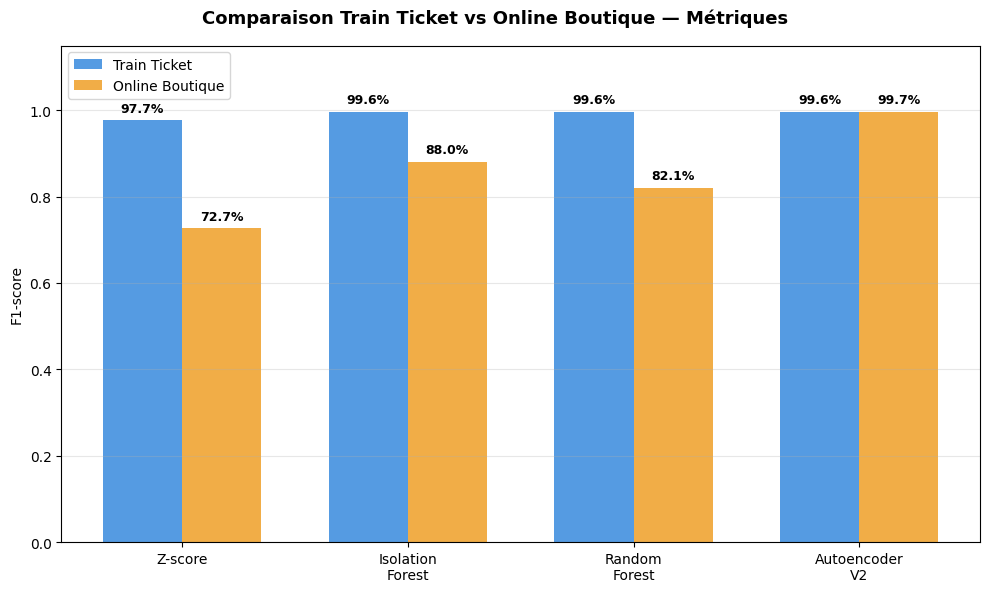

✓ Sauvegardé


In [7]:
# Sauvegarder les résultats OB
resultats_ob = pd.DataFrame([
    {'algorithme': 'Z-score', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': '3.0',
     'VP': res_z['VP'], 'FP': res_z['FP'], 'FN': res_z['FN'],
     'precision': res_z['precision'], 'rappel': res_z['rappel'],
     'f1': res_z['f1']},
    {'algorithme': 'Isolation Forest', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'contamination=0.10',
     'VP': res_if['VP'], 'FP': res_if['FP'], 'FN': res_if['FN'],
     'precision': res_if['precision'], 'rappel': res_if['rappel'],
     'f1': res_if['f1']},
    {'algorithme': 'Random Forest', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'class_weight=balanced',
     'VP': res_rf['VP'], 'FP': res_rf['FP'], 'FN': res_rf['FN'],
     'precision': res_rf['precision'], 'rappel': res_rf['rappel'],
     'f1': res_rf['f1']},
    {'algorithme': 'Autoencoder V2', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'par_fenetre_P50',
     'VP': int(vp), 'FP': int(fp), 'FN': int(fn),
     'precision': round(p, 4), 'rappel': round(r, 4),
     'f1': round(f, 4)},
])

resultats_all = pd.read_csv(RESULTS / 'resultats_detection.csv')
resultats_all = pd.concat([resultats_all, resultats_ob], ignore_index=True)
resultats_all = resultats_all.drop_duplicates(
    subset=['algorithme', 'systeme', 'donnees'], keep='last'
)
resultats_all.to_csv(RESULTS / 'resultats_detection.csv', index=False)

# Graphique comparatif TT vs OB
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Comparaison Train Ticket vs Online Boutique — Métriques',
             fontsize=13, fontweight='bold')

algos = ['Z-score', 'Isolation\nForest', 'Random\nForest', 'Autoencoder\nV2']
f1_tt = [0.977, 0.996, 0.996, 0.996]
f1_ob = [0.727, 0.880, 0.821, 0.997]

x     = np.arange(len(algos))
width = 0.35
ax.bar(x - width/2, f1_tt, width, label='Train Ticket', color='#378ADD', alpha=0.85)
ax.bar(x + width/2, f1_ob, width, label='Online Boutique', color='#EF9F27', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(algos)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (tt, ob) in enumerate(zip(f1_tt, f1_ob)):
    ax.text(i - width/2, tt + 0.02, f'{tt:.1%}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, ob + 0.02, f'{ob:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '01_comparaison_TT_OB_metriques.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé")

## 6. Sauvegarde des résultats

On sauvegarde les résultats des 4 algorithmes  
sur les métriques d'Online Boutique dans le CSV global  
pour la comparaison finale avec Train Ticket.

In [8]:
# Sauvegarder les résultats OB
resultats_ob = pd.DataFrame([
    {'algorithme': 'Z-score', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': '3.0',
     'VP': res_z['VP'], 'FP': res_z['FP'], 'FN': res_z['FN'],
     'precision': round(res_z['precision'],4), 'rappel': round(res_z['rappel'],4),
     'f1': round(res_z['f1'],4)},
    {'algorithme': 'Isolation Forest', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'contamination=0.10',
     'VP': res_if['VP'], 'FP': res_if['FP'], 'FN': res_if['FN'],
     'precision': round(res_if['precision'],4), 'rappel': round(res_if['rappel'],4),
     'f1': round(res_if['f1'],4)},
    {'algorithme': 'Random Forest', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'class_weight=balanced',
     'VP': res_rf['VP'], 'FP': res_rf['FP'], 'FN': res_rf['FN'],
     'precision': round(res_rf['precision'],4), 'rappel': round(res_rf['rappel'],4),
     'f1': round(res_rf['f1'],4)},
    {'algorithme': 'Autoencoder V2', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'par_fenetre_P50',
     'VP': int(vp), 'FP': int(fp), 'FN': int(fn),
     'precision': round(p,4), 'rappel': round(r,4), 'f1': round(f,4)},
])

resultats_all = pd.read_csv(RESULTS / 'resultats_detection.csv')
resultats_all = pd.concat([resultats_all, resultats_ob], ignore_index=True)
resultats_all = resultats_all.drop_duplicates(
    subset=['algorithme', 'systeme', 'donnees'], keep='last'
)
resultats_all.to_csv(RESULTS / 'resultats_detection.csv', index=False)

print("✓ Résultats sauvegardés")
print()
ob = resultats_all[resultats_all['systeme'] == 'Online Boutique']
print("=== Online Boutique — Métriques ===")
print(ob[['algorithme','f1','VP','FP','FN']].to_string(index=False))

✓ Résultats sauvegardés

=== Online Boutique — Métriques ===
      algorithme     f1  VP  FP  FN
         Z-score 0.7273  96   0  72
Isolation Forest 0.8800 132   0  36
   Random Forest 0.8211 117   0  51
  Autoencoder V2 0.9970 168   1   0
